In [45]:
# Taken from: https://stackoverflow.com/questions/65483030/notch-reject-filtering-in-python
import cv2
import numpy as np
import matplotlib.pyplot as plt

#------------------------------------------------------
def notch_reject_filter(shape, d0=9, u_k=0, v_k=0):
    P, Q = shape
    # Initialize filter with zeros
    H = np.zeros((P, Q))

    # Traverse through filter
    for u in range(0, P):
        for v in range(0, Q):
            # Get euclidean distance from point D(u,v) to the center
            D_uv = np.sqrt((u - P / 2 + u_k) ** 2 + (v - Q / 2 + v_k) ** 2)
            D_muv = np.sqrt((u - P / 2 - u_k) ** 2 + (v - Q / 2 - v_k) ** 2)

            if D_uv <= d0 or D_muv <= d0:
                H[u, v] = 0.0
            else:
                H[u, v] = 1.0

    return H

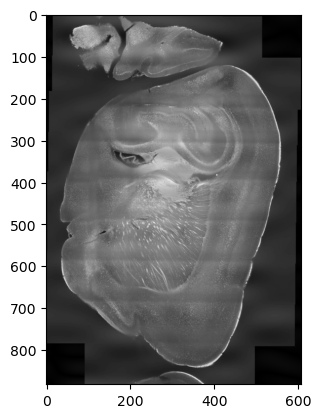

True

In [50]:
img = cv2.imread('image.png', 0)

f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
phase_spectrumR = np.angle(fshift)
magnitude_spectrum = 20*np.log(np.abs(fshift))

img_shape = img.shape

NotchFilter = notch_reject_filter(img_shape, 4, 10, 0)


NotchRejectCenter = fshift * NotchFilter 
NotchReject = np.fft.ifftshift(NotchRejectCenter)
inverse_NotchReject = np.fft.ifft2(NotchReject)  # Compute the inverse DFT of the result


Result = np.abs(inverse_NotchReject)

plt.imshow(Result, cmap='gray')
plt.show()

cv2.imwrite('image_filtered.png', Result)
cv2.imwrite('notch_filter.png', NotchFilter*255)
cv2.imwrite('frequency_domain.png', magnitude_spectrum)

(882, 608)

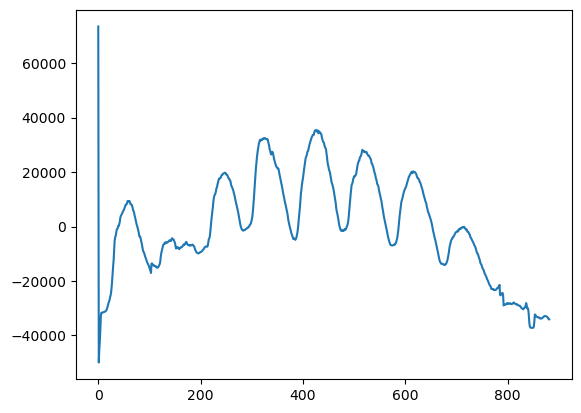

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from PIL import ImageFilter


im = Image.open("image.png")

#im.show()

# im2 = im.filter(ImageFilter.MinFilter(11))
# im2.show()

data = np.asarray(im, dtype="int32")
summed = data.sum(axis=1)
plt.plot(summed[:,0] - np.mean(summed[:,0]))

#plt.plot(np.abs(np.fft.fft(summed[:,0]-np.mean(summed[:,0]))))

#im3 = im.filter(ImageFilter.Kernel((3, 3),(0, 0, 0, -1, 1, 0, 0, 0, 0), 1, 0)) 
#im3.show()

In [24]:
summed.shape

(882, 4)